In [148]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/house-prices/sample_submission.csv
/kaggle/input/house-prices/data_description.txt
/kaggle/input/house-prices/train.csv
/kaggle/input/house-prices/test.csv


In [149]:
base = pd.read_csv('/kaggle/input/house-prices/train.csv')

In [150]:
base.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [151]:
base.shape

(1460, 81)

The dataset shows few rows and many columns

In [152]:
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

## Exploring empty values

In [153]:
#Exploring data
base.isnull().sum().sort_values(ascending=False)

PoolQC         1453
MiscFeature    1406
Alley          1369
Fence          1179
MasVnrType      872
               ... 
ExterQual         0
Exterior2nd       0
Exterior1st       0
RoofMatl          0
SalePrice         0
Length: 81, dtype: int64

In [154]:
(base.isnull().sum()/base.shape[0]).sort_values(ascending=False)

PoolQC         0.995205
MiscFeature    0.963014
Alley          0.937671
Fence          0.807534
MasVnrType     0.597260
                 ...   
ExterQual      0.000000
Exterior2nd    0.000000
Exterior1st    0.000000
RoofMatl       0.000000
SalePrice      0.000000
Length: 81, dtype: float64

In [155]:
#Remove the columns where the value is less than 10%

(base.isnull().sum()/base.shape[0])>0.1

Id               False
MSSubClass       False
MSZoning         False
LotFrontage       True
LotArea          False
                 ...  
MoSold           False
YrSold           False
SaleType         False
SaleCondition    False
SalePrice        False
Length: 81, dtype: bool

In [156]:
base.columns[(base.isnull().sum()/base.shape[0])>0.1]

Index(['LotFrontage', 'Alley', 'MasVnrType', 'FireplaceQu', 'PoolQC', 'Fence',
       'MiscFeature'],
      dtype='object')

In [157]:
remove = base.columns[(base.isnull().sum()/base.shape[0])>0.1]
remove

Index(['LotFrontage', 'Alley', 'MasVnrType', 'FireplaceQu', 'PoolQC', 'Fence',
       'MiscFeature'],
      dtype='object')

In [158]:
base = base.drop(remove, axis =1)

# Let's create a first model to check how much we are wrong and then plan how to improve. To do this:
    - Let's eliminate the text columns
    - We need to handle empty values
    - Let's choose some algorithms to test and an error evaluation method

In [159]:
#Select the numeric columns
cols = base.columns[base.dtypes != 'object']
cols

Index(['Id', 'MSSubClass', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')

In [160]:
# Create a new base with this values
base2 = base.loc[:,cols]
base2.head(3)

,Id,MSSubClass,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,1,60,8450,7,5,2003,2003,196.0,706,0,...,0,61,0,0,0,0,0,2,2008,208500
1,2,20,9600,6,8,1976,1976,0.0,978,0,...,298,0,0,0,0,0,0,5,2007,181500
2,3,60,11250,7,5,2001,2002,162.0,486,0,...,0,42,0,0,0,0,0,9,2008,223500


In [161]:
base2.isnull().sum().sort_values(ascending=False).head(3)

GarageYrBlt    81
MasVnrArea      8
Id              0
dtype: int64

In [162]:
#replace null values with -1
base2 = base2.fillna(-1)

## Creating a Model

In [163]:
X = base2.drop('SalePrice',axis=1)
y = base2.SalePrice

In [164]:
from sklearn.model_selection import train_test_split

In [165]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [166]:
#Linear Regression
from sklearn import linear_model
reg_lr = linear_model.LinearRegression()
reg_lr.fit(X_train, y_train)
y_lr = reg_lr.predict(X_test)

In [167]:
# Decision Tree regression
from sklearn import tree
reg_dtr = tree.DecisionTreeRegressor(random_state = 42).fit(X_train, y_train)
y_dtr = reg_dtr.predict(X_test)

In [168]:
# KNN regression
from sklearn.neighbors import KNeighborsClassifier
reg_knn = KNeighborsClassifier(n_neighbors=3).fit(X_train, y_train)
y_knn = reg_knn.predict(X_test)

In [169]:
#Gradient bosting regression

from sklearn import ensemble
reg_gb = ensemble.GradientBoostingRegressor(learning_rate=0.1, n_estimators=400, random_state=42, criterion = 'squared_error').fit(X_train, y_train)
y_gb = reg_gb.predict(X_test)


In [170]:
import xgboost as xgb
reg_xgb = xgb.XGBRegressor(n_estimators=400, max_depth=9, eta=0.1, subsample=0.7, colsample_bytree=0.8, random_state=42).fit(X_train, y_train)
y_xgb = reg_xgb.predict(X_test)


In [171]:
#evaluating the errors
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

# Linear Regression Error
print(mean_absolute_error(y_test,y_lr))
print(mean_squared_error(y_test,y_lr))


23763.187393064585
1533982883.4448678


In [172]:
# Decision Tree
print(mean_absolute_error(y_test,y_dtr))
print(mean_squared_error(y_test,y_dtr))


27580.78838174274
2530245114.701245


In [173]:
# KNN
print(mean_absolute_error(y_test,y_knn))
print(mean_squared_error(y_test,y_knn))


43795.141078838176
4508421084.763486


In [174]:
# GB
print(mean_absolute_error(y_test,y_gb))
print(mean_squared_error(y_test,y_gb))

17564.8494396449
1116164534.312858


In [175]:
# XGB
print(mean_absolute_error(y_test,y_xgb))
print(mean_squared_error(y_test,y_xgb))

18208.80835872666
953034831.9364612


## Visually plotting the relationship of y_test to predictions

In [176]:
import matplotlib.pyplot as plt

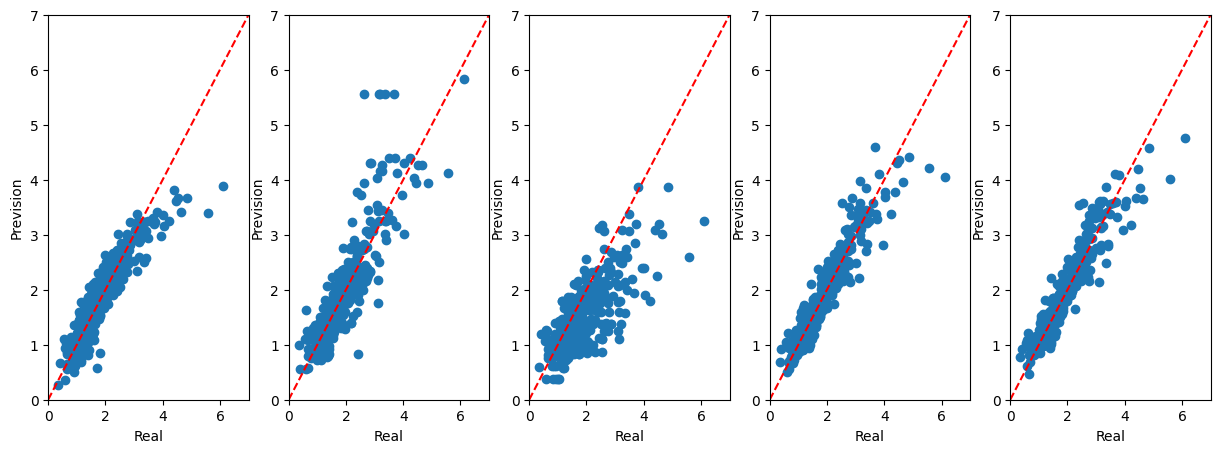

In [177]:
fig, ax = plt.subplots (ncols=5,figsize=(15,5))

ax[0].scatter(y_test/100000,y_lr/100000)
ax[0].plot([0,700000],[0,700000],'--r')
ax[1].scatter(y_test/100000,y_dtr/100000)
ax[1].plot([0,700000],[0,700000],'--r')
ax[2].scatter(y_test/100000,y_knn/100000)
ax[2].plot([0,700000],[0,700000],'--r')
ax[3].scatter(y_test/100000,y_gb/100000)
ax[3].plot([0,700000],[0,700000],'--r')
ax[4].scatter(y_test/100000,y_xgb/100000)
ax[4].plot([0,700000],[0,700000],'--r')

ax[0].set(xlim=(0,7),ylim=(0,7))
ax[0].set_xlabel('Real')
ax[0].set_ylabel('Prevision')

ax[1].set(xlim=(0,7),ylim=(0,7))
ax[1].set_xlabel('Real')
ax[1].set_ylabel('Prevision')

ax[2].set(xlim=(0,7),ylim=(0,7))
ax[2].set_xlabel('Real')
ax[2].set_ylabel('Prevision')

ax[3].set(xlim=(0,7),ylim=(0,7))
ax[3].set_xlabel('Real')
ax[3].set_ylabel('Prevision')

ax[4].set(xlim=(0,7),ylim=(0,7))
ax[4].set_xlabel('Real')
ax[4].set_ylabel('Prevision')

plt.show()

## Prevision

In [193]:
test_dt = pd.read_csv('/kaggle/input/house-prices/test.csv')

In [194]:
test_dt.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [195]:
dt = test_dt.drop(remove, axis = 1)

In [196]:
cls2 = dt.columns[dt.dtypes != 'object']
cls2

Index(['Id', 'MSSubClass', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold'],
      dtype='object')

In [197]:
dt = dt.loc[:, cls2]

In [198]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 36 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   LotArea        1459 non-null   int64  
 3   OverallQual    1459 non-null   int64  
 4   OverallCond    1459 non-null   int64  
 5   YearBuilt      1459 non-null   int64  
 6   YearRemodAdd   1459 non-null   int64  
 7   MasVnrArea     1444 non-null   float64
 8   BsmtFinSF1     1458 non-null   float64
 9   BsmtFinSF2     1458 non-null   float64
 10  BsmtUnfSF      1458 non-null   float64
 11  TotalBsmtSF    1458 non-null   float64
 12  1stFlrSF       1459 non-null   int64  
 13  2ndFlrSF       1459 non-null   int64  
 14  LowQualFinSF   1459 non-null   int64  
 15  GrLivArea      1459 non-null   int64  
 16  BsmtFullBath   1457 non-null   float64
 17  BsmtHalfBath   1457 non-null   float64
 18  FullBath

In [199]:
dt.isnull().sum().sort_values(ascending=False).head(10)

GarageYrBlt     78
MasVnrArea      15
BsmtHalfBath     2
BsmtFullBath     2
BsmtUnfSF        1
GarageCars       1
GarageArea       1
BsmtFinSF1       1
BsmtFinSF2       1
TotalBsmtSF      1
dtype: int64

In [200]:
dt = dt.fillna(-1)

In [201]:
y_pred = reg_xgb.predict(dt)

In [202]:
#Add this forecast column to the database

dt['SalePrice'] = y_pred

In [203]:
result = dt[['Id','SalePrice']]

In [204]:
result.to_csv('result.csv', index = False)